In [61]:
# ============================================================
# INVESTIGADOR COMPLETO CON LANGGRAPH
# ============================================================
# ------------------------------------------------------------
# IMPORTS INVESTIGADOR
# ------------------------------------------------------------

from typing import TypedDict, List, Dict, Annotated, Any
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.tools import tool
from langchain_cohere import ChatCohere, CohereEmbeddings
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
import os


In [62]:


load_dotenv(override=True)

SERPER_API_KEY = os.getenv("SERPER_API_KEY")
serper = GoogleSerperAPIWrapper(serper_api_key=SERPER_API_KEY)

# Ruta donde se guarda la base vectorial
FAISS_PATH = "faiss_memory"

# Inicialización de embeddings y FAISS persistente
embeddings = CohereEmbeddings(model="embed-english-v3.0")

# Cargar FAISS si existe, si no inicializar vacío
if os.path.exists(FAISS_PATH):
    try:
        vectorstore = FAISS.load_local(
            FAISS_PATH,
            embeddings,
            allow_dangerous_deserialization=True
        )
    except Exception as e:
        print(f"No se pudo cargar FAISS guardado: {e}")
else:
    vectorstore = FAISS.from_documents([], embeddings)

# Si no hay FAISS válido, crear uno con documento dummy
# if vectorstore is None:
 #    dummy_docs = [Document(page_content="dummy initialization", metadata={"type": "initialization"})]
  #   vectorstore = FAISS.from_documents(dummy_docs, embeddings)

print("✓ FAISS inicializado correctamente")

✓ FAISS inicializado correctamente


In [63]:
# ------------------------------------------------------------
# STATE DEL INVESTIGADOR
# Define los datos que viajan entre nodos
# ------------------------------------------------------------

class InvestigatorState(TypedDict):
    # Historial de mensajes para el LLM
    messages: Annotated[List[BaseMessage], add_messages]

    # Lista final de eventos (conciertos / festivales)
    events: List[Dict]

In [64]:
# ------------------------------------------------------------
# TOOLS RAG (MEMORIA VECTORIAL)
# ------------------------------------------------------------

@tool
def retrieve_events_from_memory(query: str) -> List[Dict]:
    """Recupera eventos similares desde la memoria vectorial."""
    docs = vectorstore.similarity_search(query, k=5)
    return [d.metadata for d in docs]


@tool
def store_events_in_memory(events: List[Dict]) -> str:
    """Guarda eventos normalizados en la memoria vectorial."""
    docs = []
    for e in events:
        text = f"{e.get('artist')} {e.get('city')} {e.get('country')} {e.get('date')} {e.get('type')}"
        docs.append(Document(page_content=text, metadata=e))

    if docs:
        vectorstore.add_documents(docs)
        vectorstore.save_local(FAISS_PATH)

    return "Eventos almacenados en memoria persistente"

In [65]:



# ------------------------------------------------------------
# TOOLS DE BÚSQUEDA Y FILTRADO (DECIDE EL AGENTE)
# ------------------------------------------------------------

@tool
def search_events_tool(artist: str) -> List[Dict]:
    """Busca conciertos y festivales usando Google Serper."""
    query = f"upcoming concerts and festivals {artist} Europe"
    results = serper.run(query)

    events = []
    for r in results.split("\n"):
        if r.strip():
            events.append({
                "id": hash(r),
                "artist": artist,
                "raw_text": r,
                "city": None,
                "country": None,
                "date": None,
                "price": None,
                "type": "concert",
                "link": None
            })

    return events


@tool
def filter_by_country_tool(events: List[Dict], country: str) -> List[Dict]:
    """Filtra eventos por país."""
    return [e for e in events if country.lower() in e.get("raw_text", "").lower()]


@tool
def filter_by_city_tool(events: List[Dict], city: str) -> List[Dict]:
    """Filtra eventos por ciudad."""
    return [e for e in events if city.lower() in e.get("raw_text", "").lower()]


@tool
def filter_festivals_tool(events: List[Dict]) -> List[Dict]:
    """Devuelve solo festivales."""
    return [e for e in events if "festival" in e.get("raw_text", "").lower()]


@tool
def limit_results_tool(events: List[Dict], limit: int) -> List[Dict]:
    """Limita el número de resultados."""
    return events[:limit]

In [66]:
# ------------------------------------------------------------
# LÓGICA INTERNA 
# Estas funciones para normalizar
# ------------------------------------------------------------

def remove_duplicates(events: List[Dict]) -> List[Dict]:
    return list({e["id"]: e for e in events}.values())


def sort_by_date(events: List[Dict]) -> List[Dict]:
    return sorted(events, key=lambda e: e.get("date") or "9999-99-99")


def normalize_price(events: List[Dict]) -> List[Dict]:
    for e in events:
        if e.get("price") and "€" not in e["price"]:
            e["price"] = f"{e['price']}€"
        if not e.get("price"):
            e["price"] = "Por confirmar"
    return events


def normalize_location(events: List[Dict]) -> List[Dict]:
    for e in events:
        e["city"] = e.get("city") or "Por confirmar"
        e["country"] = e.get("country") or "Por confirmar"
    return events


def normalize_type(events: List[Dict]) -> List[Dict]:
    for e in events:
        if e.get("type") not in ("concert", "festival"):
            e["type"] = "concert"
    return events


def normalize_events(events: List[Dict]) -> List[Dict]:
    events = remove_duplicates(events)
    events = sort_by_date(events)
    events = normalize_price(events)
    events = normalize_location(events)
    events = normalize_type(events)
    return events




In [67]:
# ------------------------------------------------------------
# NODO INVESTIGADOR (AGENTE CON LLM)
# Decide si usar tools o no
# ------------------------------------------------------------

def investigator_node(state: InvestigatorState) -> InvestigatorState:
    system_prompt = (
    "Eres un INVESTIGADOR DE EVENTOS MUSICALES especializado en conciertos y festivales.\n"
    "Trabajas siguiendo un FLUJO RAG ESTRICTO con memoria vectorial.\n\n"

    "FLUJO OBLIGATORIO (NO TE LO SALTES):\n"
    "1. SIEMPRE comienza usando la herramienta retrieve_events_from_memory para comprobar\n"
    "   si existen eventos relevantes previamente almacenados.\n\n"

    "2. SI retrieve_events_from_memory NO devuelve eventos relevantes,\n"
    "   "
    "   DEBES usar search_events_tool para buscar información externa.\n\n"

    "3. Cuando una herramienta devuelva eventos:\n"
    "   - Devuelve los resultados como una LISTA DE OBJETOS (no solo texto).\n"
    "   - Cada evento debe ser un diccionario con los campos estándar del sistema.\n\n"

    "4. Después de obtener eventos nuevos:\n"
    "   - Aplica los filtros solicitados por el usuario (país, ciudad, festivales, límite).\n"
    "   - Considera los resultados como DATOS NUEVOS.\n\n"

    "5. TODOS los eventos nuevos deben guardarse obligatoriamente usando\n"
    "   la herramienta store_events_in_memory para futuras consultas.\n\n"

    "REGLAS IMPORTANTES:\n"
    "- NO inventes eventos ni fechas.\n"
    "- NO respondas solo con texto si hay eventos disponibles.\n"
    "- NO finalices la respuesta sin pasar por herramientas cuando sea necesario.\n"
    "- Prioriza siempre la reutilización de memoria antes de buscar fuera.\n\n"

    "Objetivo final: proporcionar eventos reales, reutilizables y persistentes."
)


    llm = ChatCohere(
        model="command-a-03-2025",
        temperature=0,
        preamble=system_prompt
    )

    llm_with_tools = llm.bind_tools([
        retrieve_events_from_memory,
        search_events_tool,
        filter_by_country_tool,
        filter_by_city_tool,
        filter_festivals_tool,
        limit_results_tool,
        store_events_in_memory
    ])

    # Invocar el LLM
    response = llm_with_tools.invoke(state["messages"])

    # Normalizar eventos si existen en el state
    events = state.get("events", [])
    if events:
        events = normalize_events(events)

    return {
        "messages": [response],
        "events": events
    }

In [68]:

# ------------------------------------------------------------
# NODO POST-PROCESAMIENTO (CAPTURA EVENTOS DE LAS TOOLS)
# Extrae eventos generados por las herramientas 
# ------------------------------------------------------------

def merge_events_node(state: InvestigatorState) -> InvestigatorState:
    messages = state["messages"]
    events = state.get("events", [])

    last_msg = messages[-1]

    # Si el último mensaje es resultado de una tool y es lista de eventos
    if isinstance(last_msg.content, list):
        events = last_msg.content

    if events:
        events = normalize_events(events)
        store_events_in_memory.invoke({"events": events})

    return {
        "messages": messages,
        "events": events
    }



# Función para enrutamiento personalizado
def route_after_investigator(state: InvestigatorState):
    """
    Decide si llamar a tools o terminar
    """
    messages = state.get("messages", [])
    if messages:
        last_msg = messages[-1]
        # Si hay tool_calls, ir a tools; si no, terminar
        if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
            return "tools"
    return "END"




In [69]:
# ------------------------------------------------------------
# CONSTRUCCIÓN DEL GRAFO
# ------------------------------------------------------------

# Crear el grafo indicando el State
workflow = StateGraph(InvestigatorState)

# Registrar nodos
workflow.add_node("investigador", investigator_node)
workflow.add_node("merge", merge_events_node)


workflow.add_node(
    "tools",
    ToolNode([
        retrieve_events_from_memory,
        search_events_tool,
        filter_by_country_tool,
        filter_by_city_tool,
        filter_festivals_tool,
        limit_results_tool,
        store_events_in_memory
    ])
)

# Punto de entrada
workflow.add_edge(START, "investigador")

# Enrutamiento condicional:
# - si el agente solicita tools → tools
# - si no → END
workflow.add_conditional_edges(
    "investigador",
    route_after_investigator,
    {
        "tools": "tools",
        "END": END
    }
)

# Tras ejecutar una tool, volver al agente
workflow.add_edge("tools", "merge")
workflow.add_edge("merge", "investigador")


# Compilar el grafo
investigator_graph = workflow.compile()

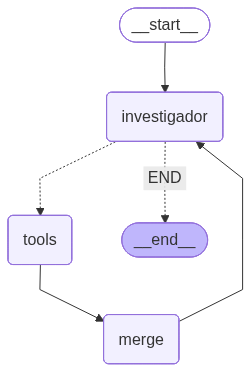

In [70]:
from IPython.display import Image, display

display(Image(investigator_graph.get_graph().draw_mermaid_png()))


In [75]:
# ------------------------------------------------------------
# EJECUCIÓN DE PRUEBAS
# ------------------------------------------------------------

print("=" * 70)
print("PRUEBA 1: Búsqueda simple con RAG activado")
print("=" * 70)

result1 = investigator_graph.invoke({
    "messages": [
        HumanMessage(content="Busca conciertos de The Weeknd en Europa")
    ],
    "events": []
})

print("\n✓ Prueba 1 completada")
print(f"Eventos encontrados: {len(result1.get('events', []))}")
if result1.get('messages'):
    print(f"Último mensaje: {result1['messages'][-1]}")

print("\n" + "=" * 70)
print("PRUEBA 2: Búsqueda con filtros (país + límite)")
print("=" * 70)

result2 = investigator_graph.invoke({
    "messages": [
        HumanMessage(content="Busca festivales de Milo J en Madrid, máximo 5 resultados")
    ],
    "events": []
})

print("\n✓ Prueba 2 completada")
print(f"Eventos encontrados: {len(result2.get('events', []))}")
if result2.get('messages'):
    print(f"Último mensaje: {result2['messages'][-1]}")

print("\n" + "=" * 70)
print("PRUEBA 3: Recuperar de memoria (si existen eventos previos)")
print("=" * 70)

result3 = investigator_graph.invoke({
    "messages": [
        HumanMessage(content="¿Qué eventos musicales tenemos guardados en la memoria?")
    ],
    "events": []
})

print("\n✓ Prueba 3 completada")
if result3.get('messages'):
    print(f"Respuesta: {result3['messages'][-1]}")

PRUEBA 1: Búsqueda simple con RAG activado

✓ Prueba 1 completada
Eventos encontrados: 0
Último mensaje: content='He encontrado los siguientes conciertos de The Weeknd en Europa:\n\n[{"artist": "The Weeknd", "city": "Manchester", "country": "UK", "date": "2026-06-11", "id": 1, "link": "https://example.com/ticketmaster", "price": null, "type": "concert"}, {"artist": "The Weeknd", "city": "Brussels", "country": null, "date": "2026-07-01", "id": 9, "link": null, "price": null, "type": "concert"}, {"artist": "The Weeknd", "city": "Manchester", "country": "UK", "date": "2026-06-12", "id": 2, "link": "https://example.com/ticketmaster", "price": null, "type": "concert"}, {"artist": "The Weeknd", "city": "Brussels", "country": null, "date": "2026-07-02", "id": 10, "link": null, "price": null, "type": "concert"}, {"artist": "The Weeknd", "city": "Copenhagen", "country": "DK", "date": "2026-06-19", "id": 3, "link": "https://example.com/ticketmaster", "price": null, "type": "concert"}]' additiona